# Handwritten Digit Recognition with MNIST

This notebook walks through a simple neural network that classifies handwritten digits from the MNIST dataset.

What you will see here:
- How to load and inspect MNIST images
- How to normalize image data
- How to build a small neural network
- How to train, evaluate, and visualize predictions

The goal is understanding, so the model stays intentionally small and readable.

## 1. Import libraries

We will use TensorFlow for the model, NumPy for array handling, and Matplotlib for plots.

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf

tf.random.set_seed(42)
np.random.seed(42)

plt.style.use('default')

## 2. Load the MNIST dataset

MNIST is built into TensorFlow, so you do not need to download a separate dataset file manually. TensorFlow will fetch it automatically the first time you run this notebook.

The images are grayscale, each one sized `28 x 28`, and the labels are digits from `0` to `9`.

In [3]:
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.mnist.load_data()

print('Training images shape:', x_train.shape)
print('Training labels shape:', y_train.shape)
print('Test images shape:', x_test.shape)
print('Test labels shape:', y_test.shape)
print('Pixel range before normalization:', x_train.min(), 'to', x_train.max())

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 3s 0us/step
Training images shape: (60000, 28, 28)
Training labels shape: (60000,)
Test images shape: (10000, 28, 28)
Test labels shape: (10000,)
Pixel range before normalization: 0 to 255


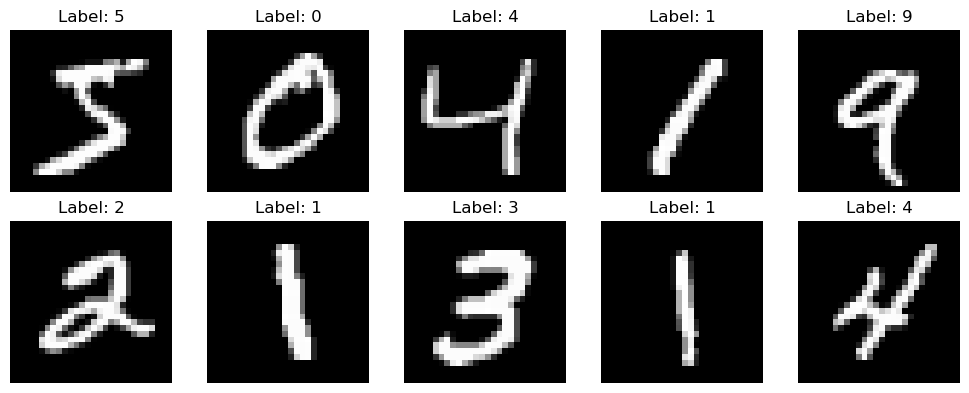

In [4]:
fig, axes = plt.subplots(2, 5, figsize=(10, 4))
for index, ax in enumerate(axes.flat):
    ax.imshow(x_train[index], cmap='gray')
    ax.set_title(f'Label: {y_train[index]}')
    ax.axis('off')

plt.tight_layout()
plt.show()

## 3. Normalize and prepare the data

Neural networks train better when inputs are scaled to a smaller numeric range. Here we divide the pixel values by `255` so they fall between `0` and `1`.

Because TensorFlow expects a channel dimension for image models, we reshape the data from `28 x 28` to `28 x 28 x 1`.

In [5]:
x_train = x_train.astype('float32') / 255.0
x_test = x_test.astype('float32') / 255.0

x_train = np.expand_dims(x_train, axis=-1)
x_test = np.expand_dims(x_test, axis=-1)

print('Training images shape after reshape:', x_train.shape)
print('Test images shape after reshape:', x_test.shape)
print('Pixel range after normalization:', x_train.min(), 'to', x_train.max())

Training images shape after reshape: (60000, 28, 28, 1)
Test images shape after reshape: (10000, 28, 28, 1)
Pixel range after normalization: 0.0 to 1.0


## 4. Build a simple neural network

This model is small on purpose:

1. `Flatten` turns the image into a one-dimensional vector
2. `Dense(128, relu)` learns patterns in the pixels
3. `Dropout(0.2)` reduces overfitting
4. `Dense(10, softmax)` outputs probabilities for the 10 digit classes

The `softmax` layer gives one probability per digit, and the highest one becomes the prediction.

In [6]:
model = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(28, 28, 1)),
    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(128, activation='relu'),
    tf.keras.layers.Dropout(0.2),
    tf.keras.layers.Dense(10, activation='softmax')
])

model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten (Flatten)               │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 101,770 (397.54 KB)

 Trainable params: 101,770 (397.54 KB)

 Non-trainable params: 0 (0.00 B)

## 5. Train the model

We keep a validation split so we can see whether the model is learning general patterns or just memorizing the training data.

In [7]:
history = model.fit(
    x_train,
    y_train,
    validation_split=0.1,
    epochs=5,
    batch_size=128,
    verbose=2,
)

Epoch 1/5
422/422 - 3s - 6ms/step - accuracy: 0.8778 - loss: 0.4307 - val_accuracy: 0.9560 - val_loss: 0.1756
Epoch 2/5
422/422 - 1s - 3ms/step - accuracy: 0.9390 - loss: 0.2101 - val_accuracy: 0.9643 - val_loss: 0.1278
Epoch 3/5
422/422 - 1s - 3ms/step - accuracy: 0.9542 - loss: 0.1583 - val_accuracy: 0.9693 - val_loss: 0.1034
Epoch 4/5
422/422 - 1s - 3ms/step - accuracy: 0.9615 - loss: 0.1294 - val_accuracy: 0.9737 - val_loss: 0.0886
Epoch 5/5
422/422 - 1s - 3ms/step - accuracy: 0.9677 - loss: 0.1099 - val_accuracy: 0.9755 - val_loss: 0.0855


## 6. Plot training curves

These plots help you check whether training is stable and whether validation performance is improving along with training performance.

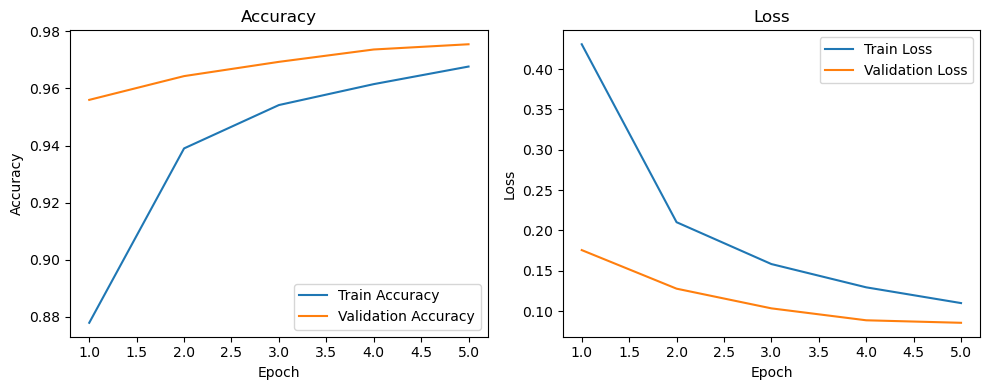

In [8]:
epochs = range(1, len(history.history['accuracy']) + 1)

plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
plt.plot(epochs, history.history['accuracy'], label='Train Accuracy')
plt.plot(epochs, history.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Accuracy')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(epochs, history.history['loss'], label='Train Loss')
plt.plot(epochs, history.history['val_loss'], label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Loss')
plt.legend()

plt.tight_layout()
plt.show()

## 7. Evaluate on the test set

The test set is the real check. It contains images the model did not see during training.

In [9]:
test_loss, test_accuracy = model.evaluate(x_test, y_test, verbose=0)
print(f'Test accuracy: {test_accuracy:.4f}')
print(f'Test loss: {test_loss:.4f}')

Test accuracy: 0.9705
Test loss: 0.0958


## 8. Inspect predictions

Here we predict a few test images and compare the predicted label with the true label. Green means correct, red means incorrect.

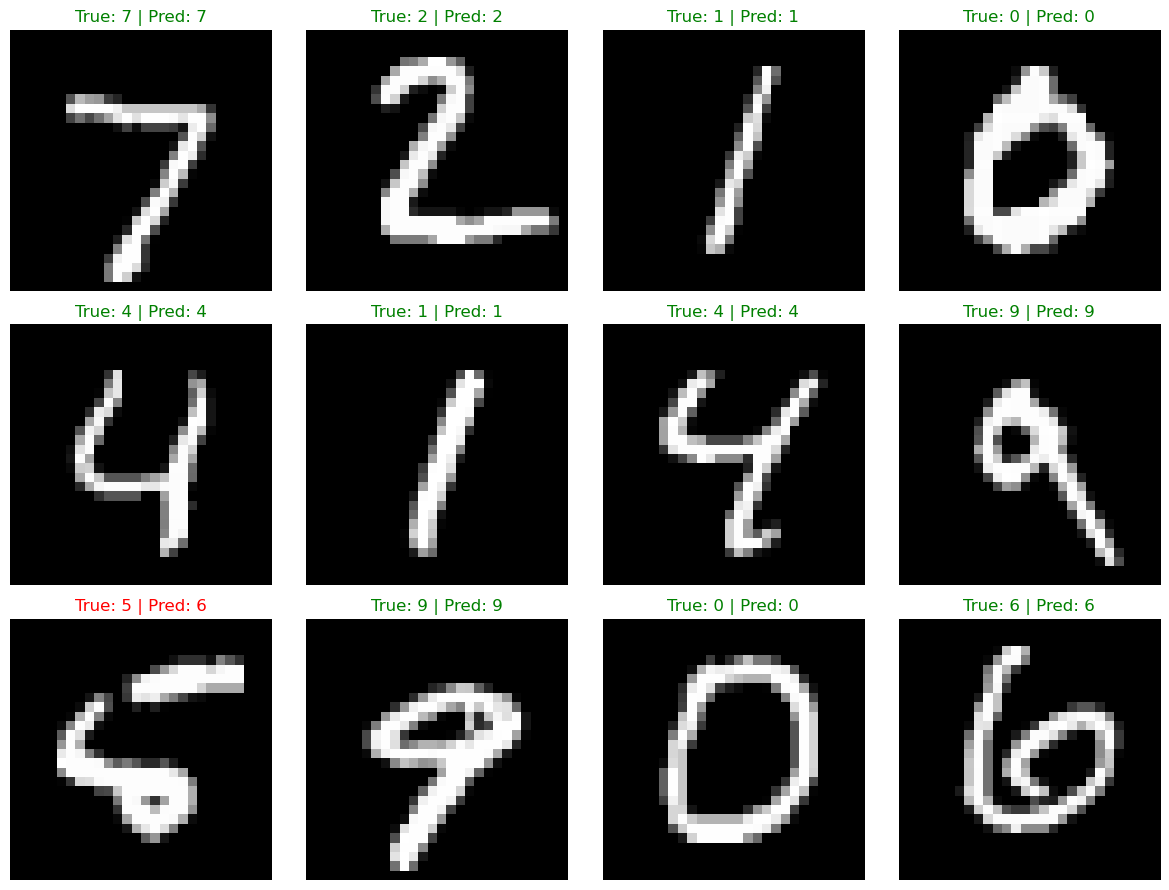

In [10]:
sample_count = 12
predictions = model.predict(x_test[:sample_count], verbose=0)
predicted_labels = np.argmax(predictions, axis=1)

rows = 3
cols = 4
plt.figure(figsize=(12, 9))

for index in range(sample_count):
    plt.subplot(rows, cols, index + 1)
    plt.imshow(x_test[index].squeeze(), cmap='gray')
    true_label = int(y_test[index])
    predicted_label = int(predicted_labels[index])
    color = 'green' if true_label == predicted_label else 'red'
    plt.title(f'True: {true_label} | Pred: {predicted_label}', color=color)
    plt.axis('off')

plt.tight_layout()
plt.show()

## 9. Save the model

If you want to reuse the trained network later, save it as a `.keras` file.

In [11]:
model.save('mnist_digit_model.keras')
print('Saved model to mnist_digit_model.keras')

Saved model to mnist_digit_model.keras
